In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm


In [2]:
ivt_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-IVT_ON0105_allmotif/pileup.npz"
with np.load(ivt_df) as data:
    ivt_df = {key: data[key] for key in data.files}
ivt_df = pd.DataFrame(ivt_df)
print(ivt_df)

          label_id     p_sum  logsum_1_p_pos  dom  count_all  count_dom  \
0                0  0.007447             0.0  0.0          5          5   
1                1  0.007037             0.0  0.0          4          4   
2                2  0.045882             0.0  0.0          4          4   
3                3  0.263237             0.0  0.0          5          5   
4                4  0.010689             0.0  0.0          5          5   
...            ...       ...             ...  ...        ...        ...   
11057693  11067910  0.036084             0.0  0.0          7          7   
11057694  11067911  0.038117             0.0  0.0          7          7   
11057695  11067912  0.012010             0.0  0.0          7          7   
11057696  11067913  0.095917             0.0  0.0          7          7   
11057697  11067914  0.175753             0.0  0.0          7          7   

          count_pos  
0                 0  
1                 0  
2                 0  
3          

In [3]:
threshold = 0.712

def calc_pm6a(df):
    return -(2-df["dom"])*df["logsum_1_p_pos"]/df["count_all"] + ((1-df["dom"])*np.log10(np.clip(1-df["dom"],1e-30,1)) + df["dom"] * np.log10(np.clip(df["dom"],1e-30,1)))*(df["count_pos"]/df["count_all"])

ivt_df["pm6a"] = calc_pm6a(ivt_df)

In [4]:
ivt_df = ivt_df[ivt_df["count_all"]>=20]

In [5]:
print(ivt_df[ivt_df["pm6a"]>=threshold])

          label_id      p_sum  logsum_1_p_pos       dom  count_all  count_dom  \
283789      283874  11.881981      -12.438559  0.650000         20         20   
310035      310126   9.366590      -16.814634  0.411765         23         17   
384696      384803  12.125738      -14.462927  0.631579         21         19   
447394      447513   5.419938      -10.073400  0.190476         24         21   
575634      575790  19.583843      -22.357082  0.552632         39         38   
...            ...        ...             ...       ...        ...        ...   
10656890  10666871  13.074717      -23.730070  0.545455         26         22   
10807924  10817951  15.481099      -16.805805  0.833333         23         18   
10850525  10860628  16.060198      -23.425392  0.695652         25         23   
10952321  10962501  14.721275      -19.194359  0.466667         33         30   
11038986  11049196  18.029720      -24.422199  0.500000         38         34   

          count_pos      pm

In [6]:
print(ivt_df)

          label_id     p_sum  logsum_1_p_pos       dom  count_all  count_dom  \
1316          1316  0.399450             0.0  0.000000         20         19   
1317          1317  0.672022             0.0  0.000000         20         18   
1318          1318  0.447963             0.0  0.000000         20         19   
1319          1319  3.133246             0.0  0.200000         20         20   
1320          1320  3.598922             0.0  0.125000         20         16   
...            ...       ...             ...       ...        ...        ...   
11056869  11067086  7.031331             0.0  0.076923         60         52   
11056870  11067087  1.943834             0.0  0.000000         38         34   
11056871  11067088  1.507107             0.0  0.027778         37         36   
11056872  11067089  1.760678             0.0  0.029412         37         34   
11056873  11067090  3.421492             0.0  0.074074         30         27   

          count_pos  pm6a  
1316       

In [29]:
path_mrna = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(path_mrna, allow_pickle=True) as data:
    df_mrna = {key: data[key] for key in data.files}


In [30]:
df_mrna = pd.DataFrame(df_mrna)
df_mrna = df_mrna[df_mrna["count_all"]>=20]
df_mrna["pm6a"] = calc_pm6a(df_mrna)
print(df_mrna)

                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000   0.606511      0.000000        0.000000          0   
1         NM_000016:1008   0.948786      0.000000        0.000000          0   
2         NM_000016:1009   2.607620      0.000000        0.000000          0   
3         NM_000016:1010   4.912612      0.000000        0.000000          0   
4         NM_000016:1014   3.237954      0.000000        0.000000          0   
...                  ...        ...           ...             ...        ...   
30894417    NR_184306:85   1.133184      0.000000        0.000000          0   
30894420    NR_184306:87   3.771550     -0.001452       -2.476578          1   
30894423    NR_184306:88   2.137289      0.000000        0.000000          0   
30894435    NR_184306:93  32.341377     -0.011076      -78.301079         23   
30894446    NR_184306:98   4.046034      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg 

In [38]:
path_ivt = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v2-20240827-175235-22-373000-token_normalise_all_context_dwell-IVT_ON0105_allmotif_pileup/pileup.pkl"
df_ivt = pd.read_pickle(path_ivt)
df_ivt = df_ivt[df_ivt["count_pm6a"]>=20]
print(df_ivt)

                label_id      pm6a  count_pm6a       dom  count_dom  mean_pred
0         NM_000016:1000  0.002688        63.0  0.000000         68   0.013365
1         NM_000016:1008  0.002567        62.0  0.015625         64   0.016574
2         NM_000016:1009  0.003085        60.0  0.000000         63   0.008780
3         NM_000016:1010  0.005679        63.0  0.028986         69   0.037653
4         NM_000016:1014  0.003921        60.0  0.015385         65   0.026991
...                  ...       ...         ...       ...        ...        ...
11056361    NR_184306:77  0.008561        19.0  0.047619         21   0.044063
11056374    NR_184306:85  0.012655        19.0  0.045455         22   0.062625
11056377    NR_184306:87  0.010210        20.0  0.000000         23   0.027729
11056380    NR_184306:88  0.013170        19.0  0.000000         20   0.019023
11056403    NR_184306:98  0.020463        15.0  0.150000         20   0.152749

[3499961 rows x 6 columns]


In [10]:
print(df_ivt[(df_ivt["pm6a"]>=0.75) & (df_ivt["dom"]>=0.75)])

                   label_id      pm6a  count_pm6a       dom  count_dom  \
509677       NM_001033:2743  0.995936        47.0  0.972973         74   
621531    NM_001042724:2592  0.959341        37.0  0.834711        121   
633575       NM_001064:1085  0.846250        58.0  0.801262        317   
746249     NM_001097615:438  0.976077        33.0  0.818182         88   
1017035   NM_001134335:2140  0.993175        30.0  1.000000         53   
...                     ...       ...         ...       ...        ...   
10334266     NR_033399:3617  0.912483        20.0  0.789474         76   
10386590     NR_036564:1067  0.881488        23.0  0.765957         94   
10415478      NR_037688:465  0.959904       307.0  0.833091       1378   
10428461     NR_037926:3083  0.975667       222.0  0.816832        606   
11029266      NR_173351:438  0.934684        21.0  0.777778         63   

          mean_pred  
509677     0.938532  
621531     0.763296  
633575     0.685465  
746249     0.749146  
1

In [11]:

def process_dorado_inferece(data_path):
    
    if os.path.exists(data_path.replace(".bed", ".pkl")):
        data_df = pd.read_pickle(data_path.replace(".bed", ".pkl"))
        return data_df
    else:
        data_df = pd.read_csv(data_path, quoting = 3, sep = "\t", header = None, dtype=str)
        ## Keep column 0, 1, 4, 9
        data_df = data_df[[0, 1, 4, 9]]
        data_df.columns = ["nmid", "pos", "depth", "pred_dorado"]
        data_df["depth"] = data_df["depth"].astype(int)
        data_df["pred_dorado"] = data_df["pred_dorado"].str.split(" ").str[1].astype(float) / 100
        data_df["label_id"] = data_df["nmid"].str.split(".").str[0] + ":" + data_df["pos"]
        data_df = data_df[["label_id", "pred_dorado","depth"]].copy()
        data_df.rename(columns = {"depth": "dorado_count"}, inplace = True)
        data_df.to_pickle(data_path.replace(".bed", ".pkl"))
    
        return data_df

In [12]:
dorado_ivt = process_dorado_inferece("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0105/ON0105/result/intermediates/old/dorado_output.modkit.bed")
print(dorado_ivt)

                label_id  pred_dorado  dorado_count
0          NM_000015:688          0.0             1
1          NM_000015:690          0.0             1
2          NM_000015:692          0.0             1
3          NM_000015:698          0.0             1
4          NM_000015:700          0.0             1
...                  ...          ...           ...
43489423  NR_184563:6132          0.0             1
43489424  NR_184563:6137          0.0             1
43489425  NR_184563:6139          0.0             1
43489426  NR_184563:6140          0.0             1
43489427  NR_184563:6142          0.0             1

[43489428 rows x 3 columns]


In [13]:
dorado_ivt = dorado_ivt[dorado_ivt["dorado_count"]>=20]
print(len(dorado_ivt))
print(len(dorado_ivt[(dorado_ivt["pred_dorado"]>0.0)]))
print(len(dorado_ivt[(dorado_ivt["pred_dorado"]>0.05)]))
print(len(dorado_ivt[(dorado_ivt["pred_dorado"]>=0.43)]))
print(len(dorado_ivt[(dorado_ivt["pred_dorado"]>=0.75)]))

3579752
2418278
1080341
19359
2465


In [14]:
dorado_mrna = process_dorado_inferece("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.bed")
print(dorado_mrna)
dorado_mrna = dorado_mrna[dorado_mrna["dorado_count"] >= 20]
print(dorado_mrna)
print(dorado_mrna[(dorado_mrna["pred_dorado"] >= 0.5)])
print(dorado_mrna[(dorado_mrna["pred_dorado"] >= 0.75)])

                label_id  pred_dorado  dorado_count
0            NM_000015:0          0.5             2
1            NM_000015:5          0.0             2
2            NM_000015:8          0.0             1
3           NM_000015:10          0.0             1
4           NM_000015:12          0.0             1
...                  ...          ...           ...
59479351  NR_184563:7515          0.0             1
59479352  NR_184563:7518          0.0             1
59479353  NR_184563:7525          0.0             2
59479354  NR_184563:7526          0.0             1
59479355  NR_184563:7528          0.0             1

[59479356 rows x 3 columns]
               label_id  pred_dorado  dorado_count
413         NM_000016:0       0.5250            40
414         NM_000016:2       0.0164            61
415         NM_000016:5       0.0822            73
417        NM_000016:21       0.0250           160
418        NM_000016:24       0.0710           155
...                 ...          ...     

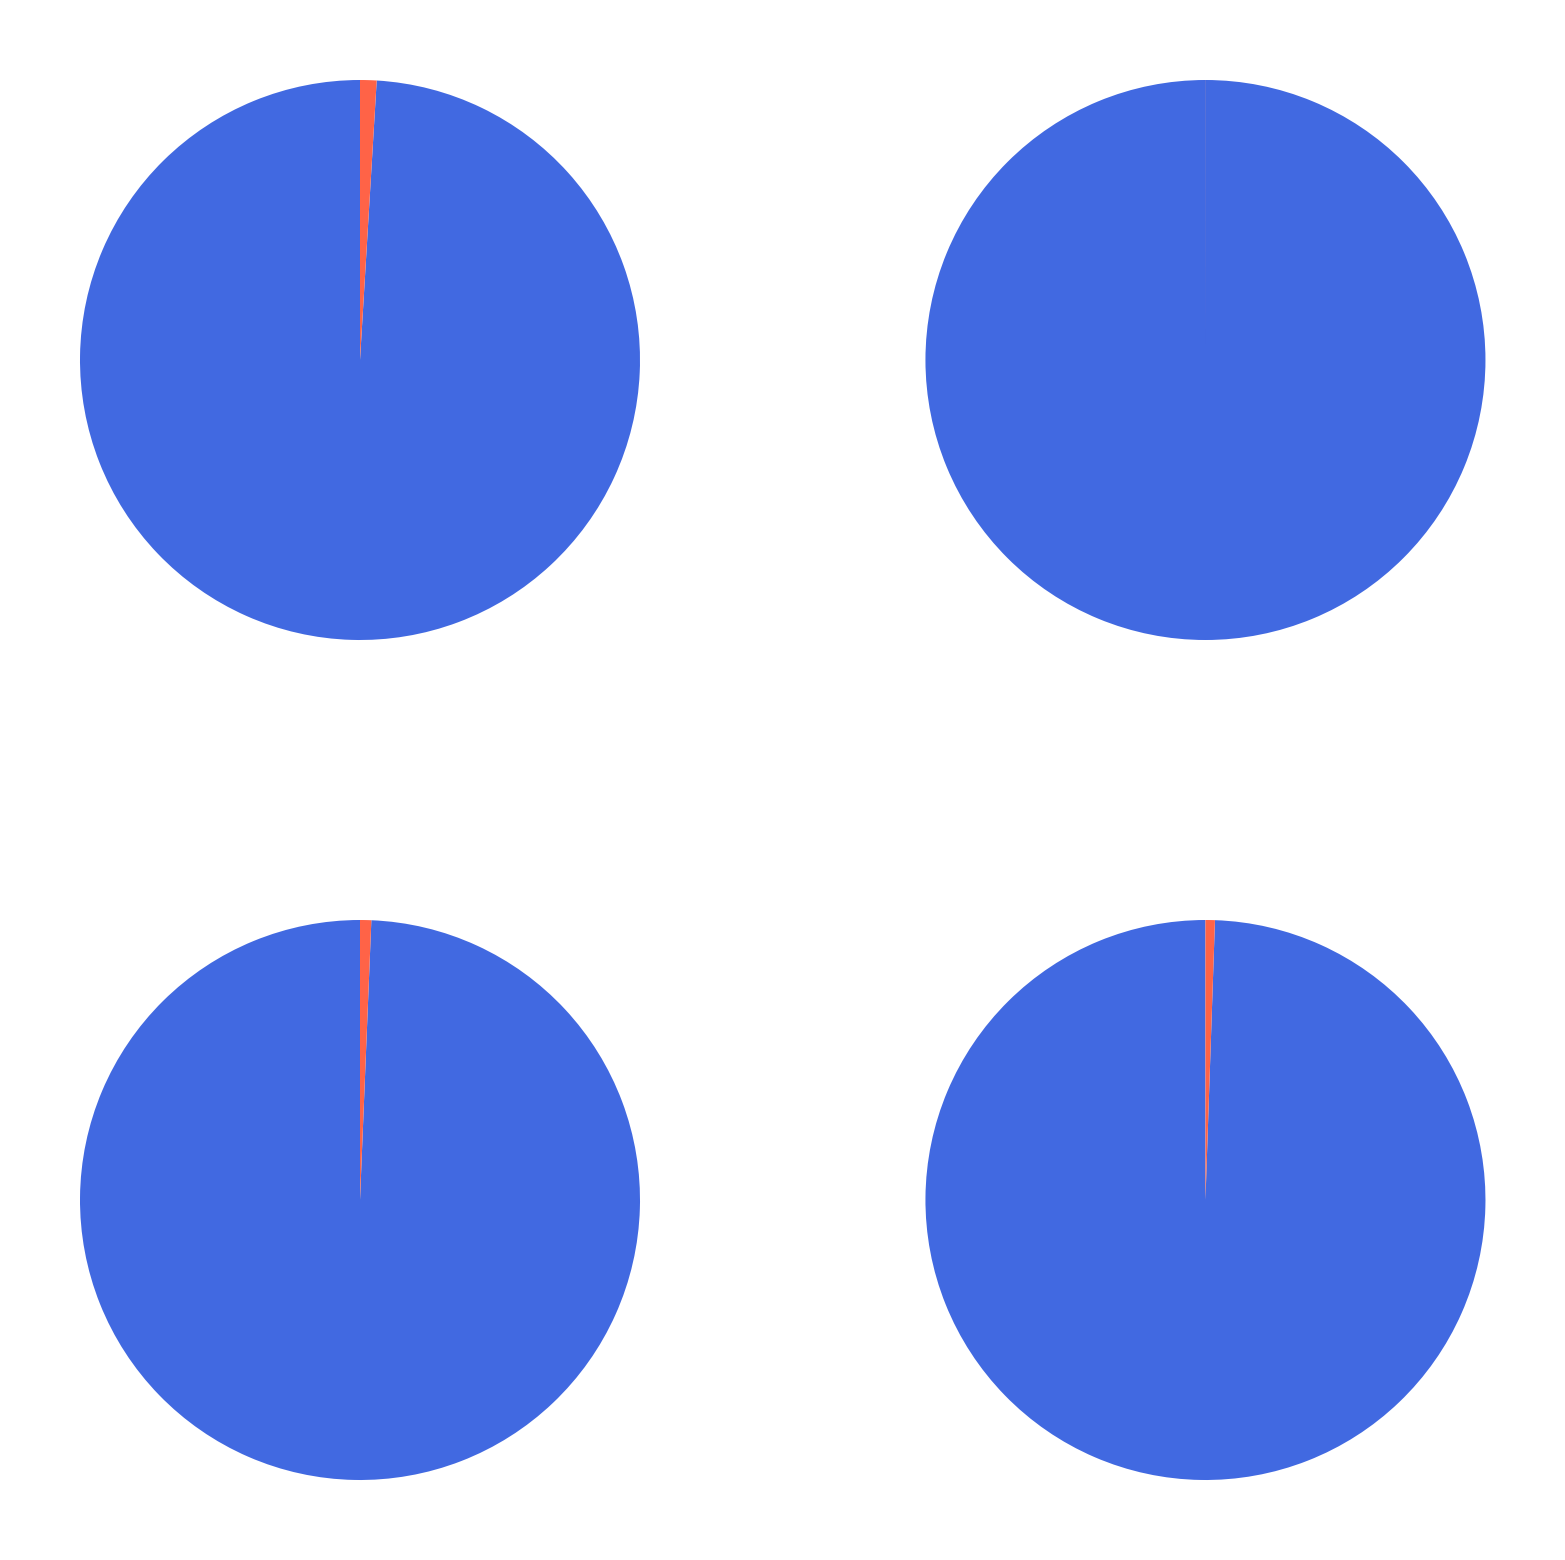

In [31]:
## Plot Pie chart
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 0, 'edgecolor':'white'}
colors = ['royalblue', 'tomato', ]
axes[0][0].pie([np.sum(df_mrna["pm6a"]<0.712), np.sum(df_mrna["pm6a"]>=0.712)],startangle = 90, colors=colors, wedgeprops=wp)
axes[0][1].pie([np.sum(ivt_df["pm6a"]<0.712), np.sum(ivt_df["pm6a"]>=0.712)],startangle = 90, colors=colors, wedgeprops=wp)
axes[1][0].pie([np.sum(dorado_mrna["pred_dorado"]<0.43),np.sum(dorado_mrna["pred_dorado"]>=0.43)],startangle = 90, colors=colors, wedgeprops=wp)
axes[1][1].pie([np.sum(dorado_ivt["pred_dorado"]<0.43),np.sum(dorado_ivt["pred_dorado"]>=0.43)],startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_ivt.pdf", format="pdf")
plt.show()

In [68]:
print(dorado_mrna[dorado_mrna["pred_dorado"]>=0.43])

                label_id  pred_dorado  dorado_count
413          NM_000016:0       0.5250            40
628        NM_000016:537       0.4412           136
1678       NM_000017:951       0.6462            65
1771      NM_000017:1321       0.4531           128
1786      NM_000017:1373       0.6311           122
...                  ...          ...           ...
59448152  NR_184066:3592       0.7000            20
59449314   NR_184072:767       0.5238            21
59449414  NR_184072:1057       0.5833            24
59475889    NR_184306:93       0.6190            42
59475941   NR_184306:250       0.4444            27

[99820 rows x 3 columns]


In [70]:
print(df_mrna[df_mrna["pm6a"]>=0.712])

                label_id       p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
105       NM_000016:1302   59.435646     -0.070924     -143.232574         53   
796       NM_000017:1321   63.604126     -0.024067     -186.799698         56   
808       NM_000017:1373   81.015984     -0.050018     -246.843155         73   
884       NM_000017:1829   18.840462     -0.010739      -54.854488         17   
2187      NM_000021:1584  140.329544     -0.049864     -470.108673        135   
...                  ...         ...           ...             ...        ...   
30890458  NR_184202:2382   10.389268     -0.004057      -12.742354          4   
30890527  NR_184202:2552    9.751621     -0.002915      -15.039289          5   
30890602  NR_184202:2708   11.693295     -0.003014      -16.873905          5   
30894404    NR_184306:77   13.487498     -0.001975      -36.067211         10   
30894435    NR_184306:93   32.341377     -0.011076      -78.301079         23   

          logsum_p_neg  log

In [39]:
## Plot Pie chart
print([np.sum(df_mrna["pm6a"]<0.712), np.sum(df_mrna["pm6a"]>=0.712)])
print([np.sum(ivt_df["pm6a"]<0.712), np.sum(ivt_df["pm6a"]>=0.712)])
print([np.sum(dorado_mrna["pred_dorado"]<0.43),np.sum(dorado_mrna["pred_dorado"]>=0.43)])
print([np.sum(dorado_ivt["pred_dorado"]<0.43),np.sum(dorado_ivt["pred_dorado"]>=0.43)])


print(np.array([np.sum(df_mrna["pm6a"]<0.712), np.sum(df_mrna["pm6a"]>=0.712)])/len(df_mrna)*100)
print(np.array([np.sum(ivt_df["pm6a"]<0.712), np.sum(ivt_df["pm6a"]>=0.712)])/len(ivt_df)*100)
print(np.array([np.sum(dorado_mrna["pred_dorado"]<0.43),np.sum(dorado_mrna["pred_dorado"]>=0.43)])/len(dorado_mrna)*100)
print(np.array([np.sum(dorado_ivt["pred_dorado"]<0.43),np.sum(dorado_ivt["pred_dorado"]>=0.43)])/len(dorado_ivt)*100)

[16246935, 155916]
[3783531, 145]
[15357434, 99820]
[3560393, 19359]
[99.04945793  0.95054207]
[9.99961677e+01 3.83225202e-03]
[99.35421906  0.64578094]
[99.45920835  0.54079165]


In [59]:
def estimate_fdr_fpr(dorado_mrna, dorado_ivt, airna_mrna, airna_ivt):
    threshold = np.arange(0.0, 3.0, 0.01)
    dorado_fdr_list = []
    airna_fdr_list = []
    dorado_fpr_list = []
    airna_fpr_list = []
    dorado_mrna = np.sort(dorado_mrna["pred_dorado"].values)
    dorado_ivt = np.sort(dorado_ivt["pred_dorado"].values)
    airna_mrna = np.sort(airna_mrna["pm6a"].values)
    airna_ivt = np.sort(airna_ivt["pm6a"].values)
    
    for t in threshold:
        dorado_ivt_positive_frac = np.sum(dorado_ivt >= t) / len(dorado_ivt)
        dorado_mrna_positive_frac = np.sum(dorado_mrna >= t) / len(dorado_mrna)
        airna_ivt_positive_frac = np.sum(airna_ivt >= t) / len(airna_ivt)
        airna_mrna_positive_frac = np.sum(airna_mrna >= t) / len(airna_mrna)
        dorado_fdr_list.append(dorado_ivt_positive_frac / dorado_mrna_positive_frac)
        airna_fdr_list.append(airna_ivt_positive_frac / airna_mrna_positive_frac)
        dorado_fpr_list.append(dorado_ivt_positive_frac)
        airna_fpr_list.append(airna_ivt_positive_frac)
    
    df = pd.DataFrame({"dorado_fdr": dorado_fdr_list, "airna_fdr": airna_fdr_list, "dorado_fpr": dorado_fpr_list, "airna_fpr": airna_fpr_list, "threshold": threshold})
    
    return df

In [60]:
df = estimate_fdr_fpr(dorado_mrna, dorado_ivt, df_mrna, ivt_df)
df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr']] = np.clip(df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr']], 0, 1)
print(df)

/tmp/ipykernel_178348/1900091143.py:17: RuntimeWarning: invalid value encountered in scalar divide
  dorado_fdr_list.append(dorado_ivt_positive_frac / dorado_mrna_positive_frac)


     dorado_fdr  airna_fdr  dorado_fpr  airna_fpr  threshold
0           1.0   1.000000    1.000000   1.000000       0.00
1           1.0   0.769013    0.641999   0.109372       0.01
2           1.0   0.774557    0.566799   0.093206       0.02
3           1.0   0.772630    0.480288   0.079949       0.03
4           1.0   0.766975    0.396578   0.069318       0.04
..          ...        ...         ...        ...        ...
295         NaN   0.000000    0.000000   0.000000       2.95
296         NaN   0.000000    0.000000   0.000000       2.96
297         NaN   0.000000    0.000000   0.000000       2.97
298         NaN   0.000000    0.000000   0.000000       2.98
299         NaN   0.000000    0.000000   0.000000       2.99

[300 rows x 5 columns]


Text(0.5, 1.0, 'log FDR vs. Threshold')

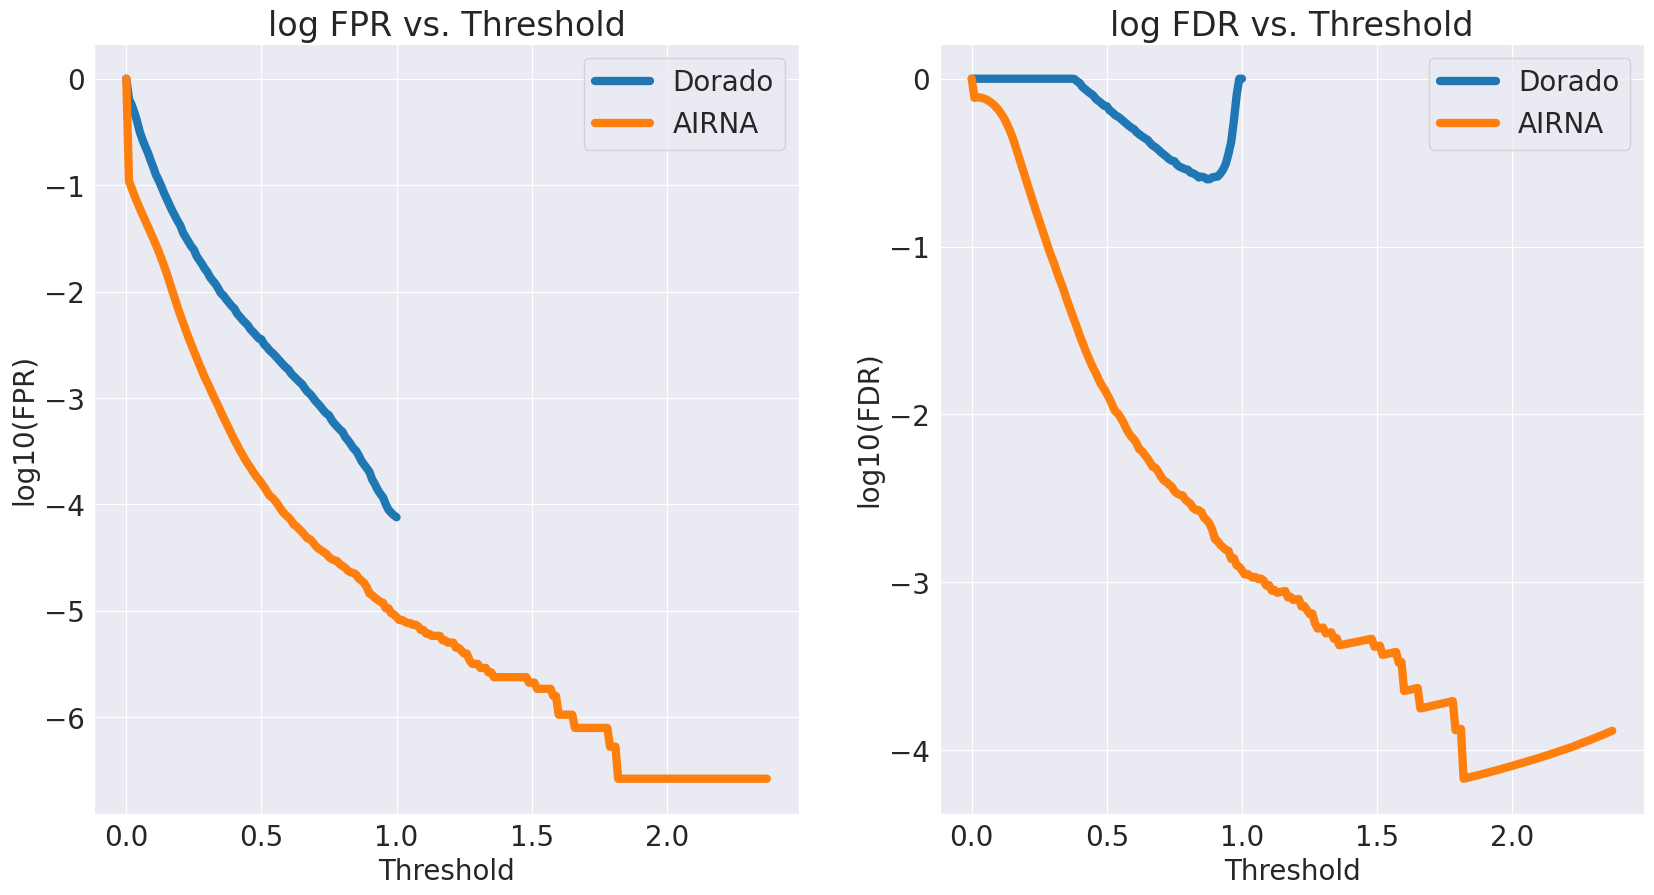

In [64]:

plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

## plot 1. log10(FPR)
axes[0].plot(df["threshold"], np.log10(df["dorado_fpr"]), label = "Dorado")
axes[0].plot(df["threshold"], np.log10(df["airna_fpr"]), label = "AIRNA")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("log10(FPR)")
axes[0].legend()
axes[0].set_title("log FPR vs. Threshold")

## plot 2. FDR
axes[1].plot(df["threshold"], np.log10(df["dorado_fdr"]), label = "Dorado")
axes[1].plot(df["threshold"], np.log10(df["airna_fdr"] ), label = "AIRNA")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("log10(FDR)")
axes[1].legend()
axes[1].set_title("log FDR vs. Threshold")




In [44]:
np.histogram(ivt_df["pm6a"], bins = 100, range = (0, 1))

(array([3369846,   61168,   50159,   40225,   33944,   28474,   24261,
          21292,   18865,   16719,   15197,   13748,   12702,   11385,
          10183,    9233,    7889,    6277,    5182,    4230,    3408,
           2839,    2438,    1933,    1619,    1424,    1200,    1005,
            896,     667,     653,     558,     467,     396,     401,
            326,     278,     247,     211,     206,     154,     149,
            115,     111,      89,      71,      79,      62,      45,
             52,      46,      50,      45,      20,      27,      30,
             33,      27,      20,      14,      19,      23,       9,
             14,      12,      14,      13,       4,      11,      12,
              9,       5,       6,       5,       9,       5,       3,
              2,       7,       4,       4,       6,       3,       1,
              3,       7,       3,       4,       6,       8,       2,
              3,       2,       2,       1,       5,       0,       4,
      

In [65]:
## Find Threshold for 0.05 and 0.01 FDR

thr_005 = df[df["airna_fdr"]<=0.05]["threshold"].min()
thr_001 = df[df["airna_fdr"]<=0.01]["threshold"].min()
thr_0001 = df[df["airna_fdr"]<=0.001]["threshold"].min()

print(thr_005, thr_001, thr_0001)

0.35000000000000003 0.55 1.09


In [58]:
print(df_mrna[df_mrna["pm6a"]>=thr_005])

                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
105       NM_000016:1302  59.435646     -0.070924     -143.232574         53   
794       NM_000017:1310  23.361641     -0.017974      -49.623337         16   
796       NM_000017:1321  63.604126     -0.024067     -186.799698         56   
808       NM_000017:1373  81.015984     -0.050018     -246.843155         73   
843       NM_000017:1583  18.562630     -0.008353      -38.703838         12   
...                  ...        ...           ...             ...        ...   
30890989   NR_184202:801  17.124971     -0.001351      -14.631237          4   
30894223   NR_184306:174   6.925148     -0.000234      -16.288748          4   
30894332    NR_184306:51   5.418068     -0.000151      -11.839625          3   
30894404    NR_184306:77  13.487498     -0.001975      -36.067211         10   
30894435    NR_184306:93  32.341377     -0.011076      -78.301079         23   

          logsum_p_neg  logsum_1_p_neg 

In [71]:
m6anet_threshold = 0.548

In [72]:
df_m6anet_ivt = "/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0105/out/data.site_proba.csv"
df_m6anet_cell = "/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0090/out/data.site_proba.csv"

df_m6anet_ivt = pd.read_csv(df_m6anet_ivt)
df_m6anet_cell = pd.read_csv(df_m6anet_cell)



In [73]:
print(np.sum(df_m6anet_ivt["probability_modified"]>=m6anet_threshold))
print(np.sum(df_m6anet_cell["probability_modified"]>=m6anet_threshold))

9397
73892


In [82]:
ivt_count = len(ivt_df)
mrna_count = len(df_mrna)

In [92]:
print(ivt_count)
print(len(dorado_ivt))

3783676
3579752


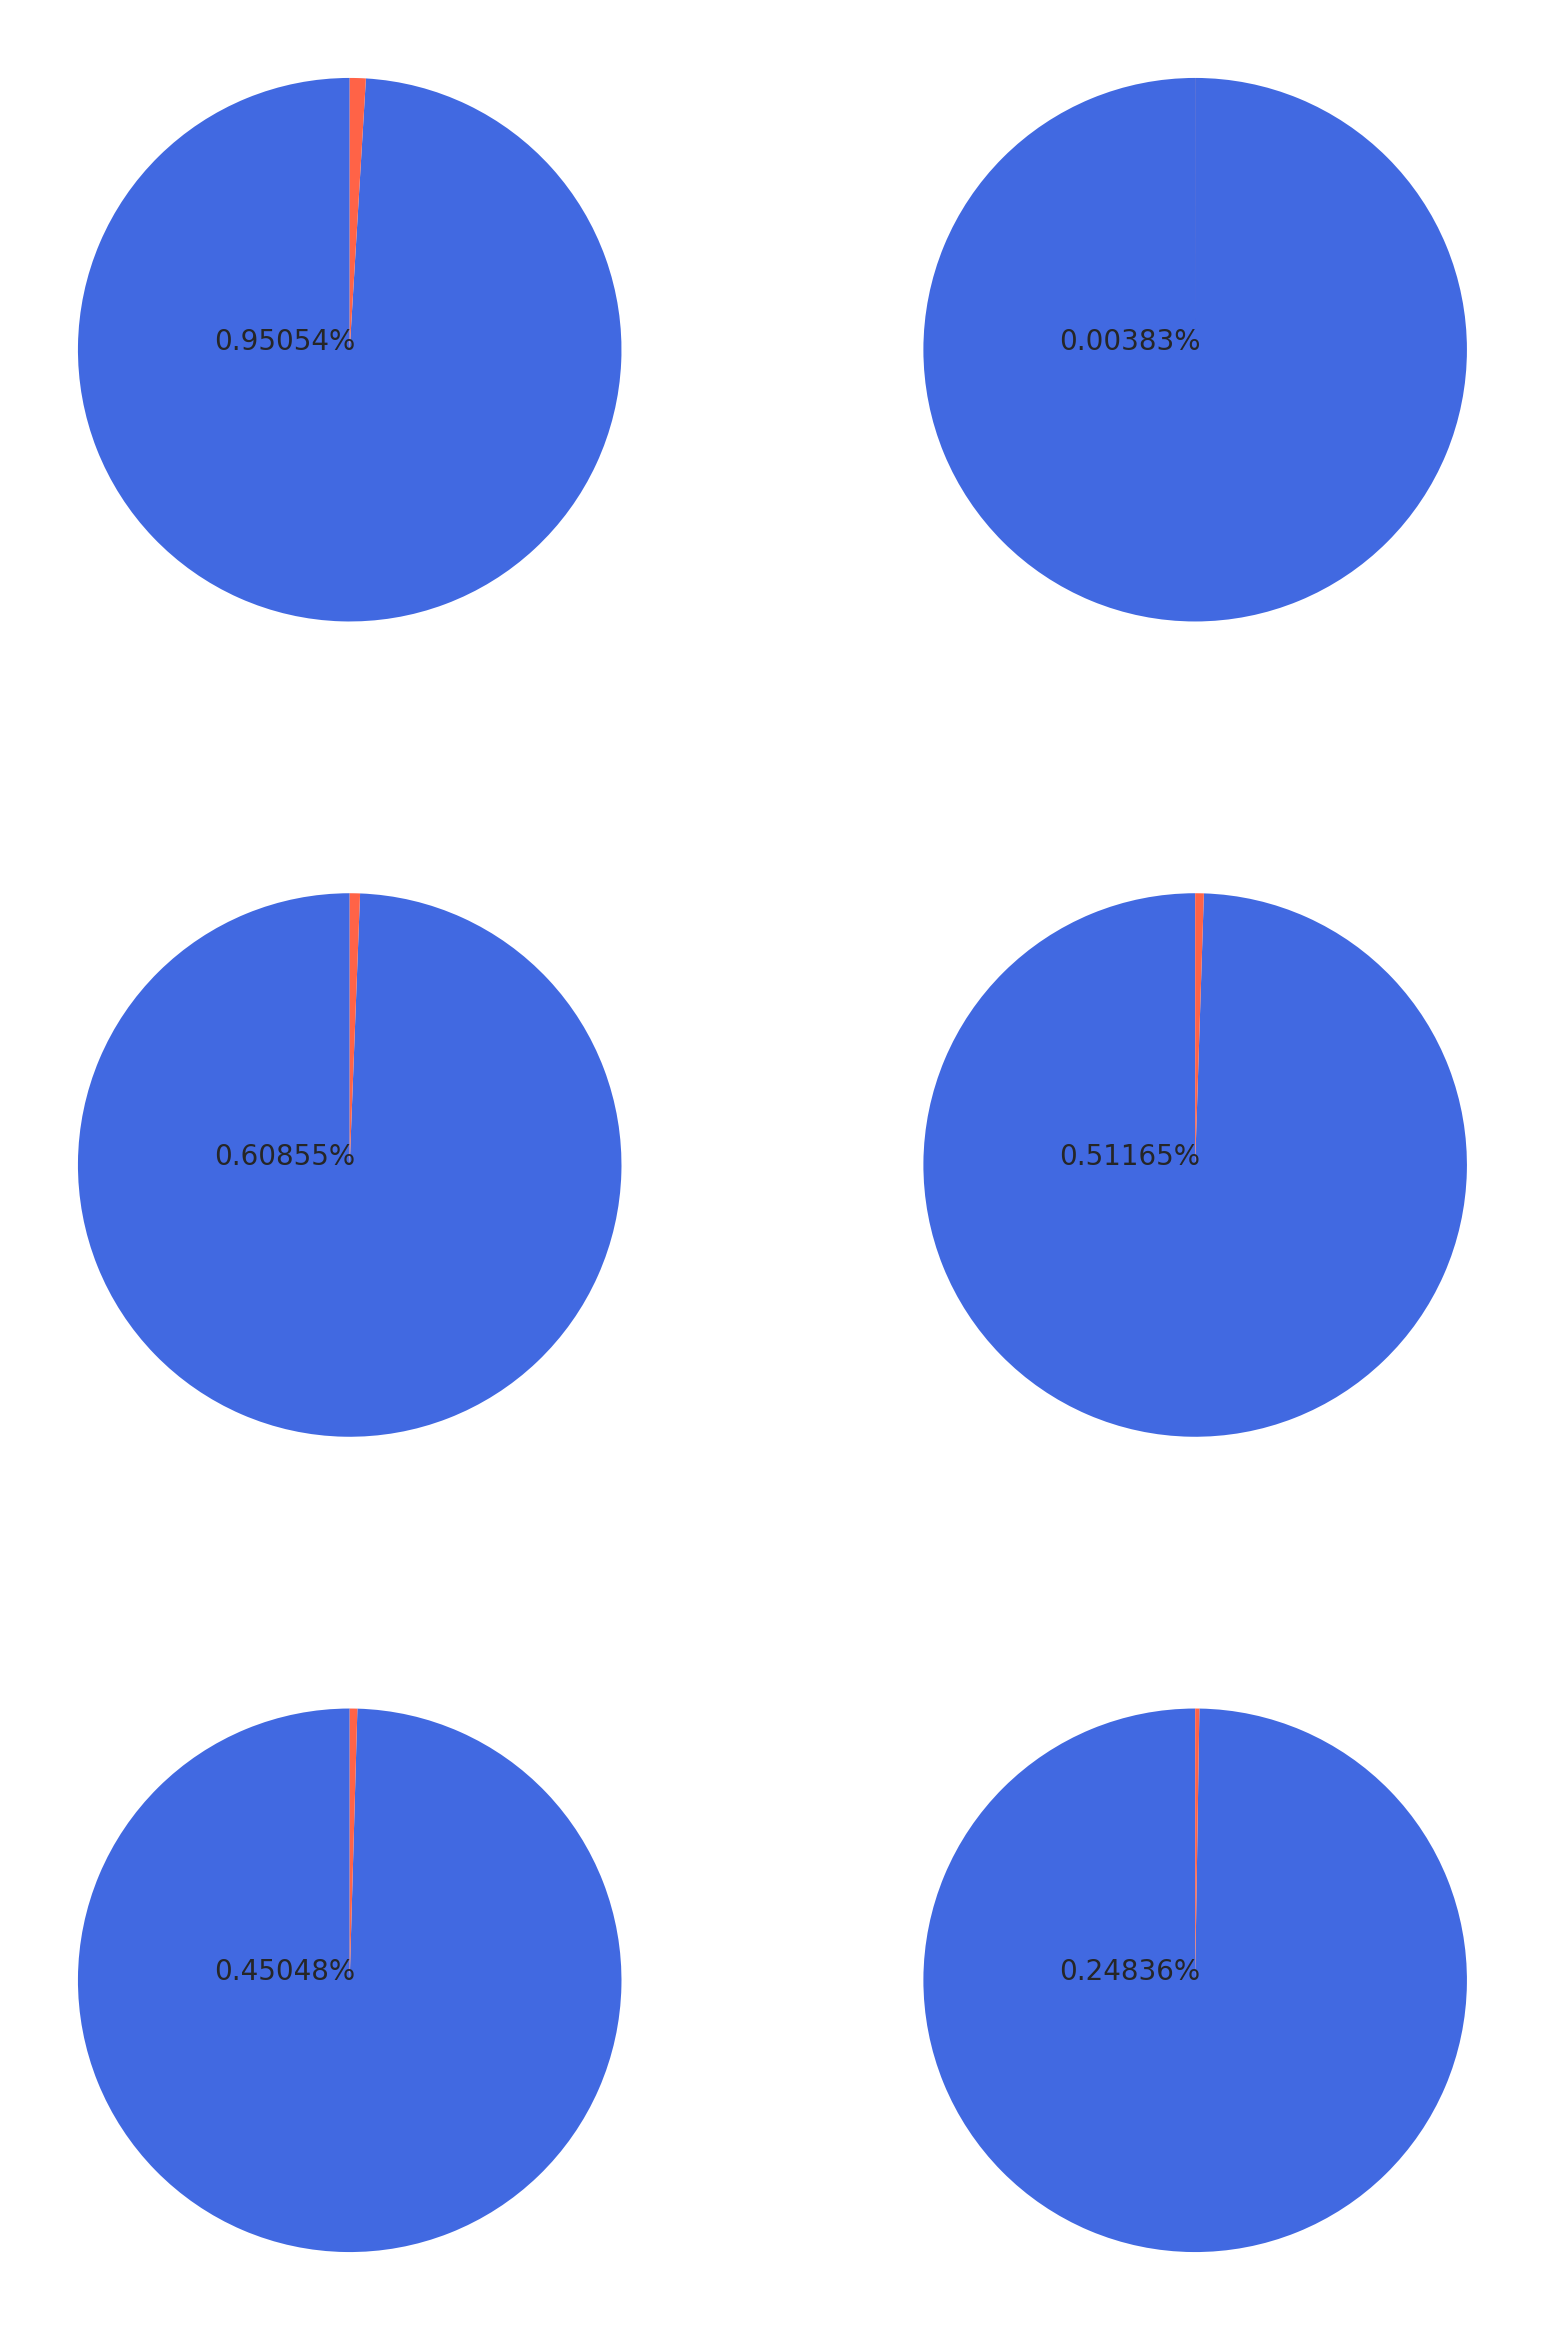

In [96]:
## Plot Pie chart
fig, axes = plt.subplots(3, 2, figsize=(20, 30))
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 0, 'edgecolor':'white'}
colors = ['royalblue', 'tomato', ]


x=np.sum(df_mrna["pm6a"]>=0.712)
axes[0][0].pie([mrna_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
axes[0][0].text(-0.5, 0, f"{100*(x/mrna_count):.5f}%", fontsize=20)
x=np.sum(ivt_df["pm6a"]>=0.712)
axes[0][1].pie([ivt_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
axes[0][1].text(-0.5, 0, f"{100*(x/ivt_count):.5f}%", fontsize=20)
x = np.sum(dorado_mrna["pred_dorado"]>=0.43)
axes[1][0].pie([mrna_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
axes[1][0].text(-0.5, 0, f"{100*(x/mrna_count):.5f}%", fontsize=20)
x = np.sum(dorado_ivt["pred_dorado"]>=0.43)
axes[1][1].pie([ivt_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
axes[1][1].text(-0.5, 0, f"{100*(x/ivt_count):.5f}%", fontsize=20)
x = np.sum(df_m6anet_cell["probability_modified"]>=.548)
axes[2][0].pie([mrna_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
axes[2][0].text(-0.5, 0, f"{100*(x/mrna_count):.5f}%", fontsize=20)
x = np.sum(df_m6anet_ivt["probability_modified"]>=0.548)
axes[2][1].pie([ivt_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
axes[2][1].text(-0.5, 0, f"{100*(x/ivt_count):.5f}%", fontsize=20)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_ivt.pdf", format="pdf")
plt.show()

In [94]:
print([np.sum(dorado_ivt["pred_dorado"]<0.43),np.sum(dorado_ivt["pred_dorado"]>=0.43)])

[3560393, 19359]


In [95]:
print(19359/len(dorado_ivt))

0.005407916526061023


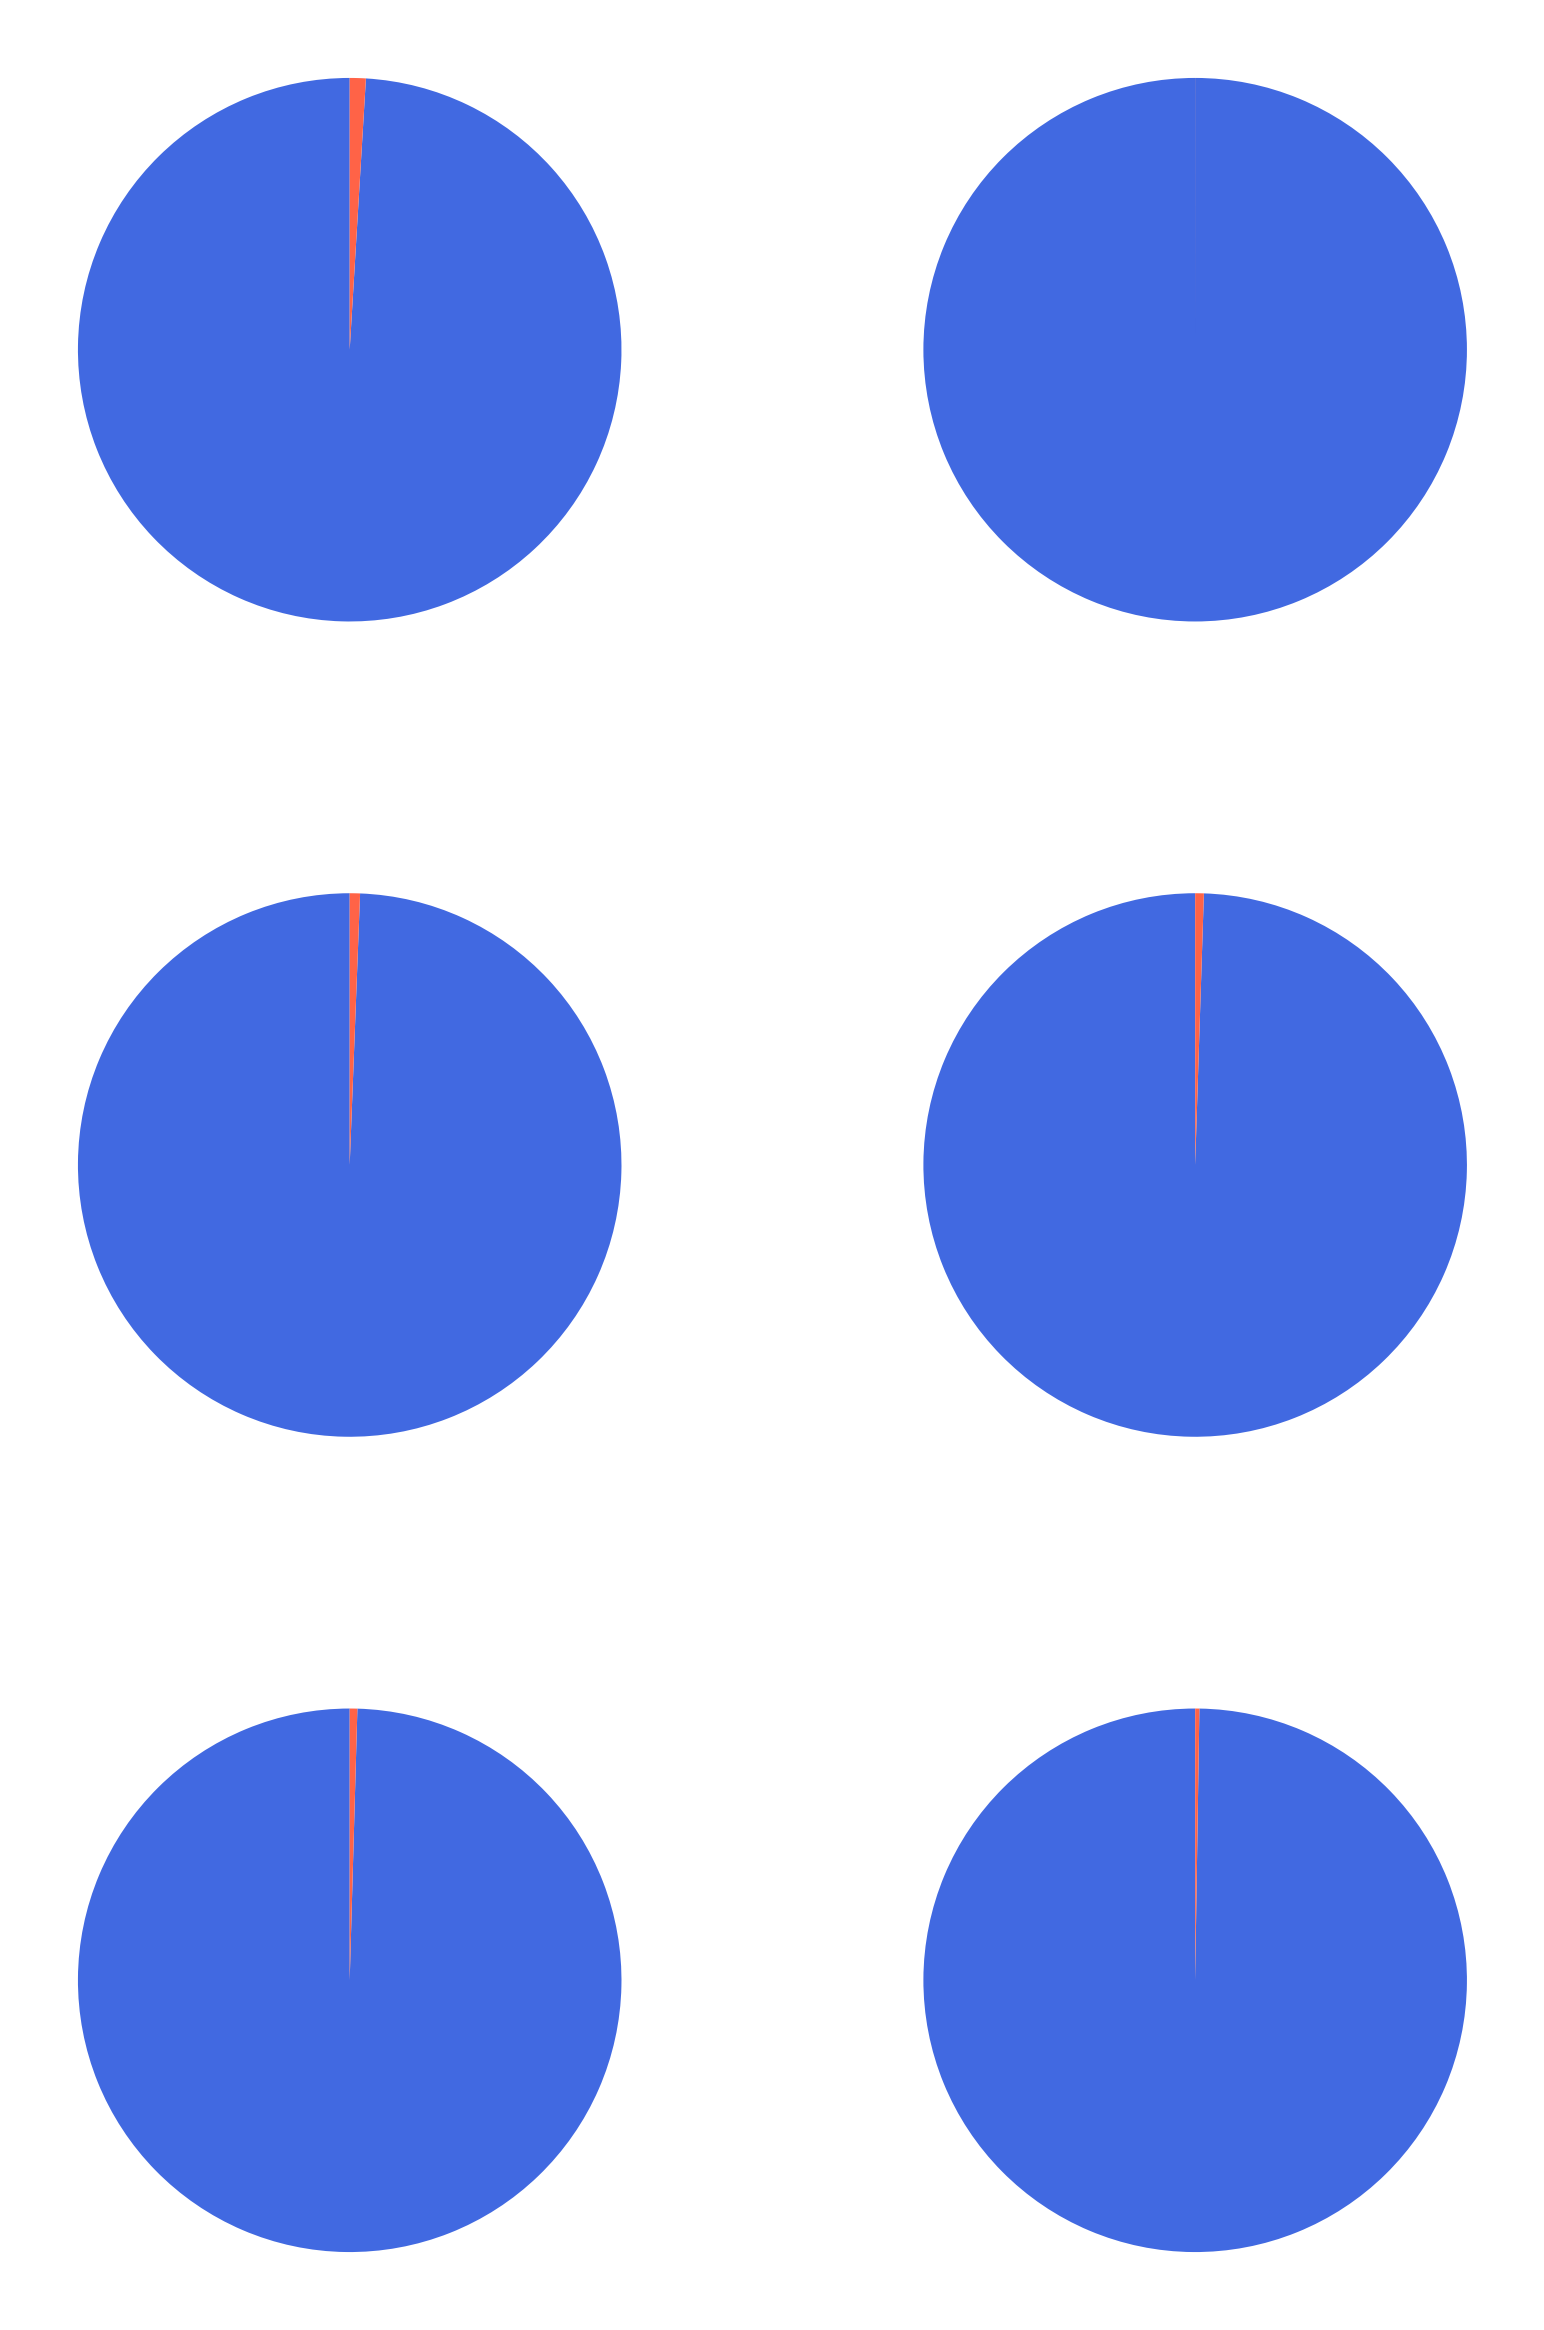

In [97]:
## Plot Pie chart
fig, axes = plt.subplots(3, 2, figsize=(20, 30))
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 0, 'edgecolor':'white'}
colors = ['royalblue', 'tomato', ]


x=np.sum(df_mrna["pm6a"]>=0.712)
axes[0][0].pie([mrna_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
x=np.sum(ivt_df["pm6a"]>=0.712)
axes[0][1].pie([ivt_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
x = np.sum(dorado_mrna["pred_dorado"]>=0.43)
axes[1][0].pie([mrna_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
x = np.sum(dorado_ivt["pred_dorado"]>=0.43)
axes[1][1].pie([ivt_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
x = np.sum(df_m6anet_cell["probability_modified"]>=.548)
axes[2][0].pie([mrna_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
x = np.sum(df_m6anet_ivt["probability_modified"]>=0.548)
axes[2][1].pie([ivt_count-x, x],startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_ivt.pdf", format="pdf")
plt.show()